## Skeleton Code

The code below provides a skeleton for the model building & training component of your project. You can add/remove/build on code however you see fit, this is meant as a starting point.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
from itertools import chain
import sklearn.model_selection as skl
from random import sample

from keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.models import Sequential, Model
from keras.applications.vgg16 import VGG16
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import preprocess_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import sklearn.metrics as sklmet

##Import any other stats/DL/ML packages you may need here. E.g. Keras, scikit-learn, etc.

Using TensorFlow backend.


## Do some early processing of your metadata for easier model training:

In [2]:
## Below is some helper code to read all of your full image filepaths into a dataframe for easier manipulation
## Load the NIH data to all_xray_df
all_xray_df = pd.read_csv('/data/Data_Entry_2017.csv')
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('/data','images*', '*', '*.png'))}
print('Scans found:', len(all_image_paths), ', Total Headers', all_xray_df.shape[0])
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df.sample(3)

Scans found: 112120 , Total Headers 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
98380,00025992_000.png,Atelectasis|Infiltration,0,25992,62,M,PA,2992,2991,0.143,0.143,NaN,/data/images_011/images/00025992_000.png
72499,00017861_000.png,No Finding,0,17861,25,M,PA,2992,2991,0.143,0.143,NaN,/data/images_008/images/00017861_000.png
17415,00004679_002.png,No Finding,2,4679,68,F,PA,2048,2500,0.168,0.168,NaN,/data/images_003/images/00004679_002.png


In [3]:

cleaned_df = all_xray_df.drop('Unnamed: 11', axis=1)
cleaned_df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800


In [4]:
## Here you may want to create some extra columns in your table with binary indicators of certain diseases 
## rather than working directly with the 'Finding Labels' column
cleaned_df = cleaned_df[cleaned_df['Patient Age'] <= 100]
all_labels = np.unique(list(chain(*cleaned_df['Finding Labels'].map(lambda x: x.split('|')).tolist())))
all_labels = [x for x in all_labels if len(x)>0]

for c_label in all_labels:
    if len(c_label)>1: # leave out empty labels
        cleaned_df[c_label] = cleaned_df['Finding Labels'].map(lambda finding: 1.0 if c_label in finding else 0)
cleaned_df.sample(3)
cleaned_df.describe()
# Todo

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Atelectasis,Cardiomegaly,Consolidation,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
count,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,...,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000,112104.000000
mean,8.574172,14345.720724,46.872574,2646.035253,2486.393153,0.155651,0.155651,0.103101,0.024763,0.041631,...,0.022443,0.015040,0.002025,0.177433,0.051550,0.538366,0.056474,0.030186,0.012756,0.047286
std,15.406734,8403.980520,16.598152,341.243771,401.270806,0.016174,0.016174,0.304092,0.155402,0.199745,...,0.148121,0.121711,0.044954,0.382037,0.221118,0.498528,0.230836,0.171100,0.112220,0.212252
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,7308.000000,35.000000,2500.000000,2048.000000,0.143000,0.143000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,183.000000,30805.000000,95.000000,3827.000000,4715.000000,0.198800,0.198800,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
## Here we can create a new column called 'pneumonia_class' that will allow us to look at 
## images with or without pneumonia for binary classification
cleaned_df['pneumonia_class'] = cleaned_df.Pneumonia == 1


## Create your training and testing data:

In [6]:
def create_splits(df, test_size=0.2, random_state=42):
    
    ## Either build your own or use a built-in library to split your original dataframe into two sets 
    ## that can be used for training and testing your model
    ## It's important to consider here how balanced or imbalanced you want each of those sets to be
    ## for the presence of pneumonia
    
    # First, split the train and validation data and ensure that a ratio of
    # positive cases of pneumonia_class are the same in both datasets
    train_data, val_data = skl.train_test_split(df, 
                                   test_size = test_size, 
                                   stratify = df['pneumonia_class'], 
                                   random_state = random_state)
    
    # Next, ensure that we have EQUAL amount of positive and negative cases of pneumonia_class 
    # in Training
    p_inds_train = train_data[train_data.pneumonia_class == 1].index.tolist()
    np_inds_train = train_data[train_data.pneumonia_class == 0].index.tolist()

    np_sample_train = sample(np_inds_train,len(p_inds_train))
    train_data = train_data.loc[p_inds_train + np_sample_train]
    
    # Since we have a very imbalance dataset where there is only 1.275% of
    # data that is account for Pneumonia cases, we will increase a ratio of
    # positive cases (Pneumonia cases) to 20% so can effectively evaluate
    # the performance of our model
    # If we are not doing this, most of the validation data will be negative
    # cases and this will be a problem when calculating metrics (e.g. model will
    # get a good performance if it outputs 0 all the time or it can have a very
    # poor performance if it misclassifies the only positive case in the validation data, etc.)
        
    p_inds_val = val_data[val_data.pneumonia_class == 1].index.tolist()
    np_inds_val = val_data[val_data.pneumonia_class == 0].index.tolist()
    
    # Number of negative cases will be 4 times greater that the positive cases
    np_sample_val = sample(np_inds_val, 4 * len(p_inds_val))
    val_data = val_data.loc[p_inds_val + np_sample_val]
    
    return train_data, val_data

# Now we can begin our model-building & training

#### First suggestion: perform some image augmentation on your data

In [7]:
def my_image_augmentation(horizontal_flip = True,
                          height_shift_range = 0.05,
                          width_shift_range = 0.1,
                          rotation_range = 5, 
                          shear_range = 0.1,
                          zoom_range = 0.05):
    
    ## recommendation here to implement a package like Keras' ImageDataGenerator
    ## with some of the built-in augmentations 
    
    ## keep an eye out for types of augmentation that are or are not appropriate for medical imaging data
    ## Also keep in mind what sort of augmentation is or is not appropriate for testing vs validation data
    
    ## STAND-OUT SUGGESTION: implement some of your own custom augmentation that's *not*
    ## built into something like a Keras package
    
    # preprocess_input function is used to ensured that the data format is suitable for the
    # pretrained vgg16 in keras
    # See the following post for more details:
    # https://stackoverflow.com/questions/47555829/preprocess-input-method-in-keras/47556342#47556342
        
    idg = ImageDataGenerator(rescale = 1. / 255.0,
                              horizontal_flip = horizontal_flip, 
                              vertical_flip = False, 
                              height_shift_range = height_shift_range, 
                              width_shift_range = width_shift_range, 
                              rotation_range = rotation_range, 
                              shear_range = shear_range,
                              zoom_range = zoom_range,
                              preprocessing_function = preprocess_input)
    
    return idg


def make_train_gen(df, IMG_SIZE = (224, 224), batch_size = 128):
    
    ## Create the actual generators using the output of my_image_augmentation for your training data
    ## Suggestion here to use the flow_from_dataframe library, e.g.:
    
#     train_gen = my_train_idg.flow_from_dataframe(dataframe=train_df, 
#                                          directory=None, 
#                                          x_col = ,
#                                          y_col = ,
#                                          class_mode = 'binary',
#                                          target_size = , 
#                                          batch_size = 
#                                          )
     # Todo
    idg = my_image_augmentation()
    train_gen = idg.flow_from_dataframe(dataframe=df, 
                                         directory=None, 
                                         x_col = 'path',
                                         y_col = 'pneumonia_class',
                                         class_mode = 'raw',
                                         shuffle = True,
                                         target_size = IMG_SIZE, 
                                         batch_size = batch_size
                                         )

    return train_gen


def make_val_gen(df, IMG_SIZE = (224, 224), batch_size = 128, shuffle=True):
    
#     val_gen = my_val_idg.flow_from_dataframe(dataframe = val_data, 
#                                              directory=None, 
#                                              x_col = ,
#                                              y_col = ',
#                                              class_mode = 'binary',
#                                              target_size = , 
#                                              batch_size = ) 

    idg = ImageDataGenerator(rescale = 1. / 255.0,
                             preprocessing_function = preprocess_input)
    val_gen = idg.flow_from_dataframe(dataframe=df, 
                                         directory=None, 
                                         x_col = 'path',
                                         y_col = 'pneumonia_class',
                                         class_mode = 'raw',
                                         target_size = IMG_SIZE, 
                                         batch_size = batch_size,
                                         shuffle = shuffle
                                         )
    
    
    # Todo
    return val_gen

In [8]:
train_data, val_data = create_splits(cleaned_df)

In [9]:
## May want to pull a single large batch of random validation data for testing after each epoch:
val_gen = make_val_gen(val_data)
valX, valY = val_gen.next()


Found 1430 validated image filenames.


In [10]:
train_gen = make_train_gen(train_data)

Found 2288 validated image filenames.


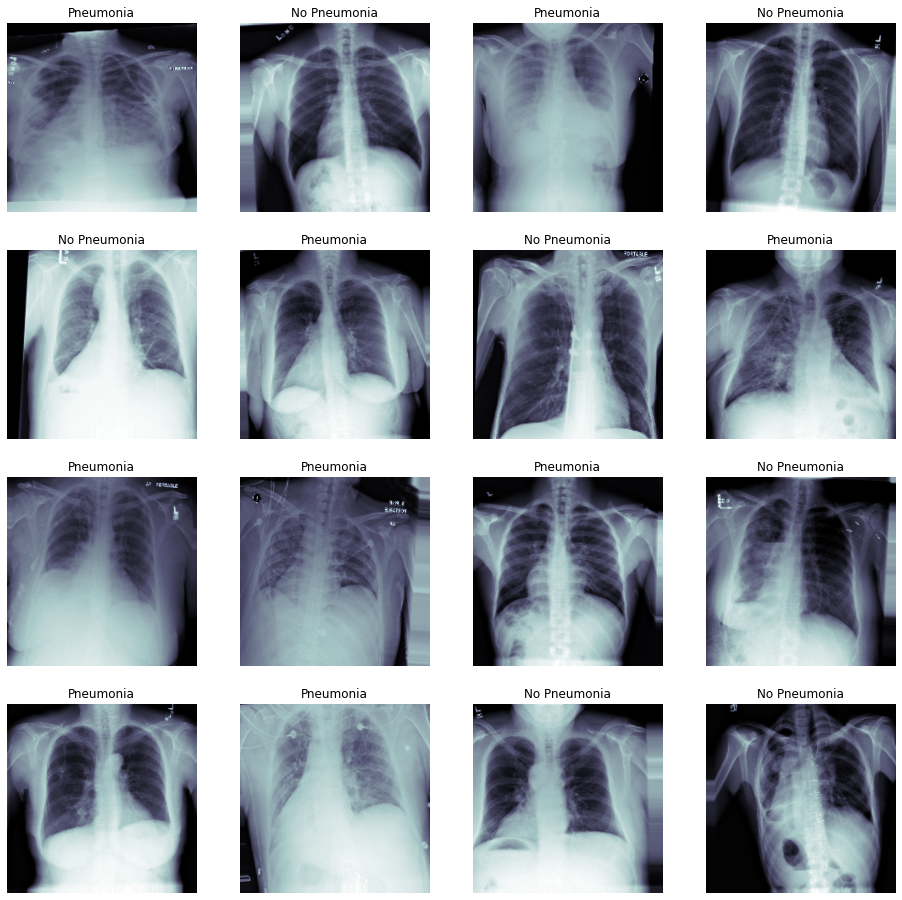

In [11]:
## May want to look at some examples of our augmented training data. 
## This is helpful for understanding the extent to which data is being manipulated prior to training, 
## and can be compared with how the raw data look prior to augmentation

t_x, t_y = next(train_gen)
fig, m_axs = plt.subplots(4, 4, figsize = (16, 16))
for (c_x, c_y, c_ax) in zip(t_x, t_y, m_axs.flatten()):
    c_ax.imshow(c_x[:,:,0], cmap = 'bone')
    if c_y == 1: 
        c_ax.set_title('Pneumonia')
    else:
        c_ax.set_title('No Pneumonia')
    c_ax.axis('off')

## Build your model: 

Recommendation here to use a pre-trained network downloaded from Keras for fine-tuning

In [12]:
def load_pretrained_model():
    
    # Use the pre-trained vgg16 for this transfer learning task
    model = VGG16(include_top=True, weights='imagenet')
    transfer_layer = model.get_layer('block5_pool')
    pretrained_model = Model(inputs=model.input,
                       outputs=transfer_layer.output)

    for layer in pretrained_model.layers[0:17]:
        layer.trainable = False    
    
    return pretrained_model


In [13]:
def build_my_model():
    
    # my_model = Sequential()
    # ....add your pre-trained model, and then whatever additional layers you think you might
    # want for fine-tuning (Flatteen, Dense, Dropout, etc.)
    
    # if you want to compile your model within this function, consider which layers of your pre-trained model, 
    # you want to freeze before you compile 
    
    # also make sure you set your optimizer, loss function, and metrics to monitor
    
    # Todo
    
    new_model = Sequential()

    # Add the convolutional part of the pretrained model.
    pretrainedModel = load_pretrained_model()
    new_model.add(pretrainedModel)

    new_model.add(GlobalAveragePooling2D())

    new_model.add(Dense(256, activation='relu'))
    new_model.add(Dropout(0.5))

    new_model.add(Dense(1, activation='sigmoid'))
    
    ## Set our optimizer, loss function, and learning rate
    optimizer = Adam(lr=2e-4)
    loss = 'binary_crossentropy'
    metrics = ['binary_accuracy','mae']
    
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    
    return new_model



## STAND-OUT Suggestion: choose another output layer besides just the last classification layer of your modele
## to output class activation maps to aid in clinical interpretation of your model's results

In [14]:
## Below is some helper code that will allow you to add checkpoints to your model,
## This will save the 'best' version of your model by comparing it to previous epochs of training

## Note that you need to choose which metric to monitor for your model's 'best' performance if using this code. 
## The 'patience' parameter is set to 10, meaning that your model will train for ten epochs without seeing
## improvement before quitting

# Todo

weight_path="{}_my_model.best.hdf5".format('xray_class')

# Monitor a training loss for this task since the validation loss is very fluctuated in this task
checkpoint = ModelCheckpoint(weight_path, 
                             monitor= 'val_loss', 
                             verbose=1, 
                             save_best_only=True, 
                             mode= 'min', 
                             save_weights_only = True)

early = EarlyStopping(monitor= 'val_loss', 
                      mode= 'min', 
                      patience=10)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.25,
                                  patience=3, min_lr=1e-5)

callbacks_list = [checkpoint, early, reduce_lr]

### Start training! 

In [15]:
my_model = build_my_model()
my_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
model_1 (Model)              (None, 7, 7, 512)         14714688  
_________________________________________________________________
global_average_pooling2d_1 ( (None, 512)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 256)               131328    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 257       
Total params: 14,846,273
Trainable params: 2,491,393
Non-trainable params: 12,354,880
_________________________________________________________________


In [16]:
## train your model
history = my_model.fit_generator(train_gen, 
                          validation_data = (valX, valY), 
                          epochs = 200, 
                          callbacks = callbacks_list)

Epoch 1/200
18/18 [==============================] - 58s 3s/step - loss: 0.7035 - binary_accuracy: 0.5446 - mae: 0.4836 - val_loss: 0.5914 - val_binary_accuracy: 0.7344 - val_mae: 0.4387

Epoch 00001: val_loss improved from inf to 0.59141, saving model to xray_class_my_model.best.hdf5
Epoch 2/200
18/18 [==============================] - 51s 3s/step - loss: 0.6882 - binary_accuracy: 0.5743 - mae: 0.4816 - val_loss: 0.5400 - val_binary_accuracy: 0.7891 - val_mae: 0.3985

Epoch 00002: val_loss improved from 0.59141 to 0.54001, saving model to xray_class_my_model.best.hdf5
Epoch 3/200
18/18 [==============================] - 51s 3s/step - loss: 0.6910 - binary_accuracy: 0.5559 - mae: 0.4852 - val_loss: 0.6040 - val_binary_accuracy: 0.7188 - val_mae: 0.4461

Epoch 00003: val_loss did not improve from 0.54001
Epoch 4/200
18/18 [==============================] - 52s 3s/step - loss: 0.6645 - binary_accuracy: 0.5953 - mae: 0.4726 - val_loss: 0.6168 - val_binary_accuracy: 0.6641 - val_mae: 0.448

##### After training for some time, look at the performance of your model by plotting some performance statistics:

Note, these figures will come in handy for your FDA documentation later in the project

In [36]:
## After training, make some predictions to assess your model's overall performance
## Note that detecting pneumonia is hard even for trained expert radiologists, 
## so there is no need to make the model perfect.
my_model.load_weights(weight_path)
pred_Y = my_model.predict(valX, batch_size = 128, verbose = True)

128/128 [==============================] - 1s 7ms/step


In [37]:
def plot_auc(t_y, p_y):
    
    ## Hint: can use scikit-learn's built in functions here like roc_curve
    
    fpr, tpr, _ = sklmet.roc_curve(t_y, p_y)
    roc_auc = sklmet.auc(fpr, tpr)
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
    lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1-Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()
    
    return

## what other performance statistics do you want to include here besides AUC? 


# def ... 
# Todo

# def ...
# Todo
def plot_precision_recall(t_y, p_y):
    '''
    Plot a Precision-Recall curve and also display the average Precision score
    '''
    fig, c_ax = plt.subplots(1,1, figsize = (9, 9))
    precision, recall, thresholds = sklmet.precision_recall_curve(t_y, p_y)
    c_ax.plot(recall, precision, label = '%s (AP Score:%0.2f)'  % ('Pneumonia', sklmet.average_precision_score(t_y,p_y)))
    c_ax.set_title('Precision-Recall curve')
    c_ax.legend()
    c_ax.set_xlabel('Recall')
    c_ax.set_ylabel('Precision')
    return precision, recall, thresholds  

def calc_f1(prec,recall):
    return 2*(prec*recall)/(prec+recall)

#Also consider plotting the history of your model training:

def plot_history(history):
    fig, m_axs = plt.subplots(1,2, figsize = (12, 4))
    m_axs[0].plot(history.history['loss'], label = "Training Loss")
    m_axs[0].plot(history.history['val_loss'], label = "Validation Loss")
    m_axs[0].set(xlabel='Epoch', ylabel='Loss')
    m_axs[0].set_yscale('log')
    m_axs[0].legend()
    m_axs[0].set_title('Training Loss vs Validation Loss');
    
    m_axs[1].plot(history.history['binary_accuracy'], label = "Training Accuracy")
    m_axs[1].plot(history.history['val_binary_accuracy'], label = "Validation Accuracy")
    m_axs[1].set(xlabel='Epoch', ylabel='Accuracy')
    m_axs[1].legend()
    m_axs[1].set_title('Training Accuracy vs Validation Accuracy');
    return

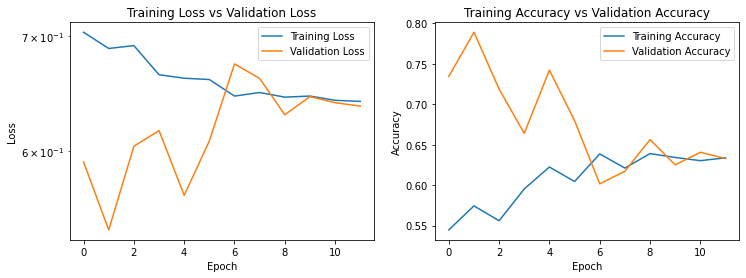

In [38]:
plot_history(history)

Once you feel you are done training, you'll need to decide the proper classification threshold that optimizes your model's performance for a given metric (e.g. accuracy, F1, precision, etc.  You decide) 

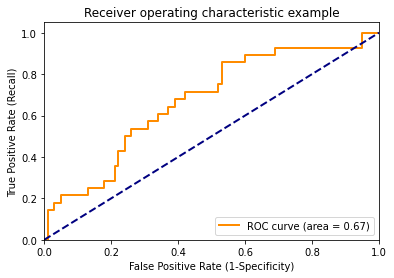

In [39]:
## Find the threshold that optimize your model's performance,
## and use that threshold to make binary classification. Make sure you take all your metrics into consideration.

# ROC Curve
plot_auc(valY, pred_Y)

In highly imbalanced classification problems, ROC AUC can be misleading because the large number of true negatives makes the false positive rate appear small, giving an overly optimistic score. Precision-Recall (PR) curves are often preferred since they focus on precision and recall of the minority positive class.


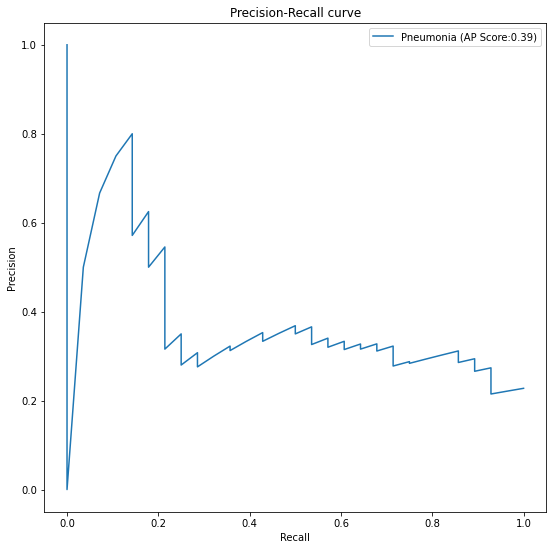

In [40]:
precision, recall, thresholds = plot_precision_recall(valY, pred_Y)

In [41]:
f1_score = calc_f1(precision, recall)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide


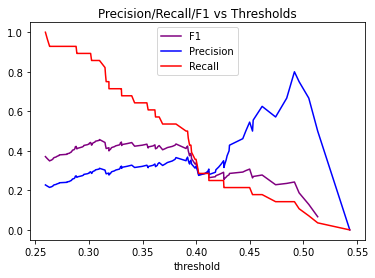

In [42]:
plt.plot(thresholds, f1_score[:-1], color='purple', label="F1")
plt.plot(thresholds, precision[:-1], color='blue', label="Precision")
plt.plot(thresholds, recall[:-1], color='red', label="Recall")

plt.legend()
plt.title('Precision/Recall/F1 vs Thresholds')
plt.xlabel('threshold');

In [43]:
started_index = 35
end_index =55
for idx in range(started_index, end_index):
    print('==== Index: {}, Threshold: {:.6f}'.format(idx, thresholds[idx]))
    print('Recall is: {:.6f}'.format(recall[idx]))    
    print('Precision is: {:.6f}'.format(precision[idx]))
    print('F1 Score is: {:.6f}'.format(f1_score[idx]))

==== Index: 35, Threshold: 0.298505
Recall is: 0.892857
Precision is: 0.284091
F1 Score is: 0.431034
==== Index: 36, Threshold: 0.300281
Recall is: 0.892857
Precision is: 0.287356
F1 Score is: 0.434783
==== Index: 37, Threshold: 0.300427
Recall is: 0.892857
Precision is: 0.290698
F1 Score is: 0.438596
==== Index: 38, Threshold: 0.301626
Recall is: 0.892857
Precision is: 0.294118
F1 Score is: 0.442478
==== Index: 39, Threshold: 0.302500
Recall is: 0.857143
Precision is: 0.285714
F1 Score is: 0.428571
==== Index: 40, Threshold: 0.303122
Recall is: 0.857143
Precision is: 0.289157
F1 Score is: 0.432432
==== Index: 41, Threshold: 0.303244
Recall is: 0.857143
Precision is: 0.292683
F1 Score is: 0.436364
==== Index: 42, Threshold: 0.303990
Recall is: 0.857143
Precision is: 0.296296
F1 Score is: 0.440367
==== Index: 43, Threshold: 0.305624
Recall is: 0.857143
Precision is: 0.300000
F1 Score is: 0.444444
==== Index: 44, Threshold: 0.306097
Recall is: 0.857143
Precision is: 0.303797
F1 Score is:

---
A threshold of 0.31(==== Index: 46, Threshold: 0.309903) was selected based on F1-score optimization while prioritizing sensitivity for pneumonia detection. At this threshold, the model achieved a recall of 85.7%, ensuring that most pneumonia cases were identified, with a precision of 31.2% and an F1-score of 0.457. This threshold was preferred over the default 0.5 threshold because clinical screening tasks prioritize minimizing false negatives.

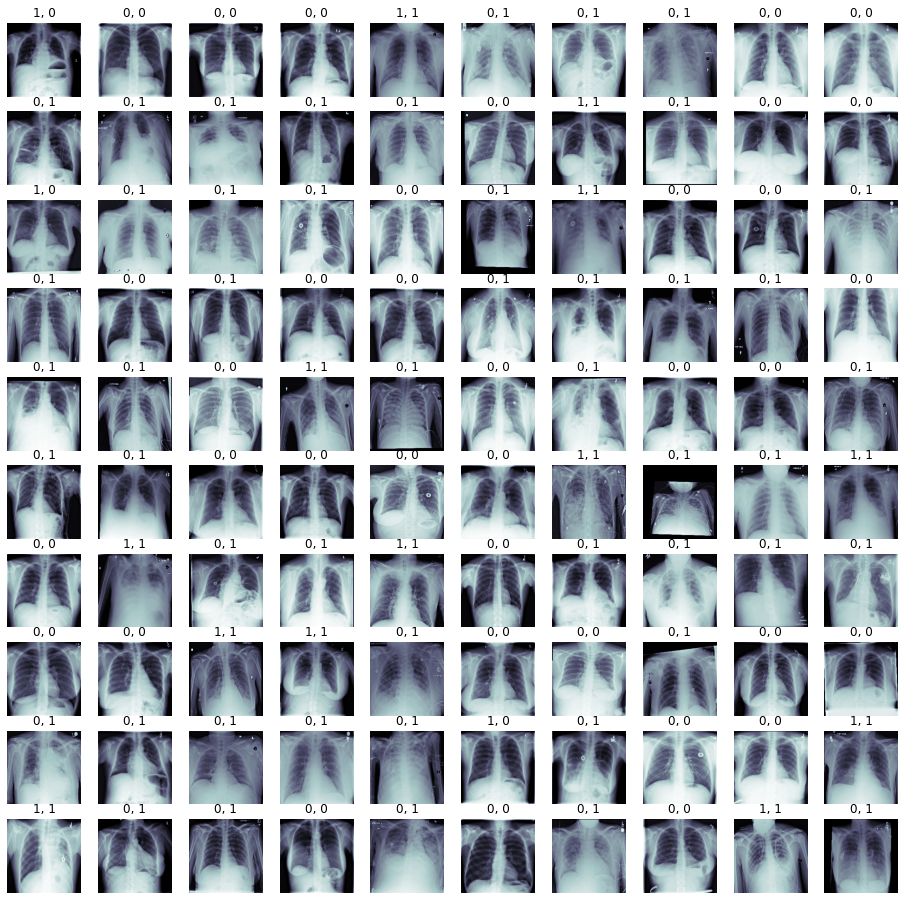

In [44]:
## Let's look at some examples of true vs. predicted with our best model: 
thresh=0.31
# Todo
ground_truth = [] 
p_out = []
fig, m_axs = plt.subplots(10, 10, figsize = (16, 16))
i = 0
for (c_x, c_y, c_ax) in zip(valX[0:100], valY[0:100], m_axs.flatten()):
    ground_truth.append(c_y)
    p_out.append(pred_Y[i] > thresh)
    c_ax.imshow(c_x[:,:,0], cmap = 'bone')
    if c_y == 1: 
        if pred_Y[i] > thresh:
            c_ax.set_title('1, 1')
        else:
            c_ax.set_title('1, 0')
    else:
        if pred_Y[i] > thresh: 
            c_ax.set_title('0, 1')
        else:
            c_ax.set_title('0, 0')
    c_ax.axis('off')
    i=i+1

In [45]:
sklmet.confusion_matrix(ground_truth, p_out)

array([[36, 48],
       [ 3, 13]])

In [46]:
print('Accuracy: {}'.format(sklmet.balanced_accuracy_score(ground_truth, p_out)))
print('Precision: {}'.format(sklmet.precision_score(ground_truth, p_out)))
print('Recall: {}'.format(sklmet.recall_score(ground_truth, p_out)))
print('F1 Score: {}'.format(sklmet.f1_score(ground_truth, p_out)))

Accuracy: 0.6205357142857143
Precision: 0.21311475409836064
Recall: 0.8125
F1 Score: 0.3376623376623376


In [47]:
## Just save model architecture to a .json:

model_json = my_model.to_json()
with open("my_model.json", "w") as json_file:
    json_file.write(model_json)